In [1]:
from tabpfn import TabPFNClassifier, TabPFNRegressor
from tabpfn.constants import ModelVersion

classifier = TabPFNClassifier.create_default_for_version(ModelVersion.V2_6)
regressor = TabPFNRegressor.create_default_for_version(ModelVersion.V2_6)

/Users/leonackermann/Desktop/on_device/ml-genetics4psychiatry/pasteur/lib/python3.12/site-packages/tabpfn_common_utils/telemetry/core/decorators.py:217: UserWarning: TabPFN model has fit_mode='fit_preprocessors', not 'fit_with_cache'. Imputation-based SHAP will be substantially slower than necessary. Construct the model with TabPFNClassifier or TabPFNRegressor (fit_mode='fit_with_cache', ...) (set BEFORE calling .fit) to enable the KV cache, then set model.executor_.keep_cache_on_device = True after .fit().
  return fn(*args, **kwargs)
/Users/leonackermann/Desktop/on_device/ml-genetics4psychiatry/pasteur/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but TabPFNRegressor was fitted with feature names
  warnings.warn(
/Users/leonackermann/Desktop/on_device/ml-genetics4psychiatry/pasteur/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but TabPFNRegressor was f

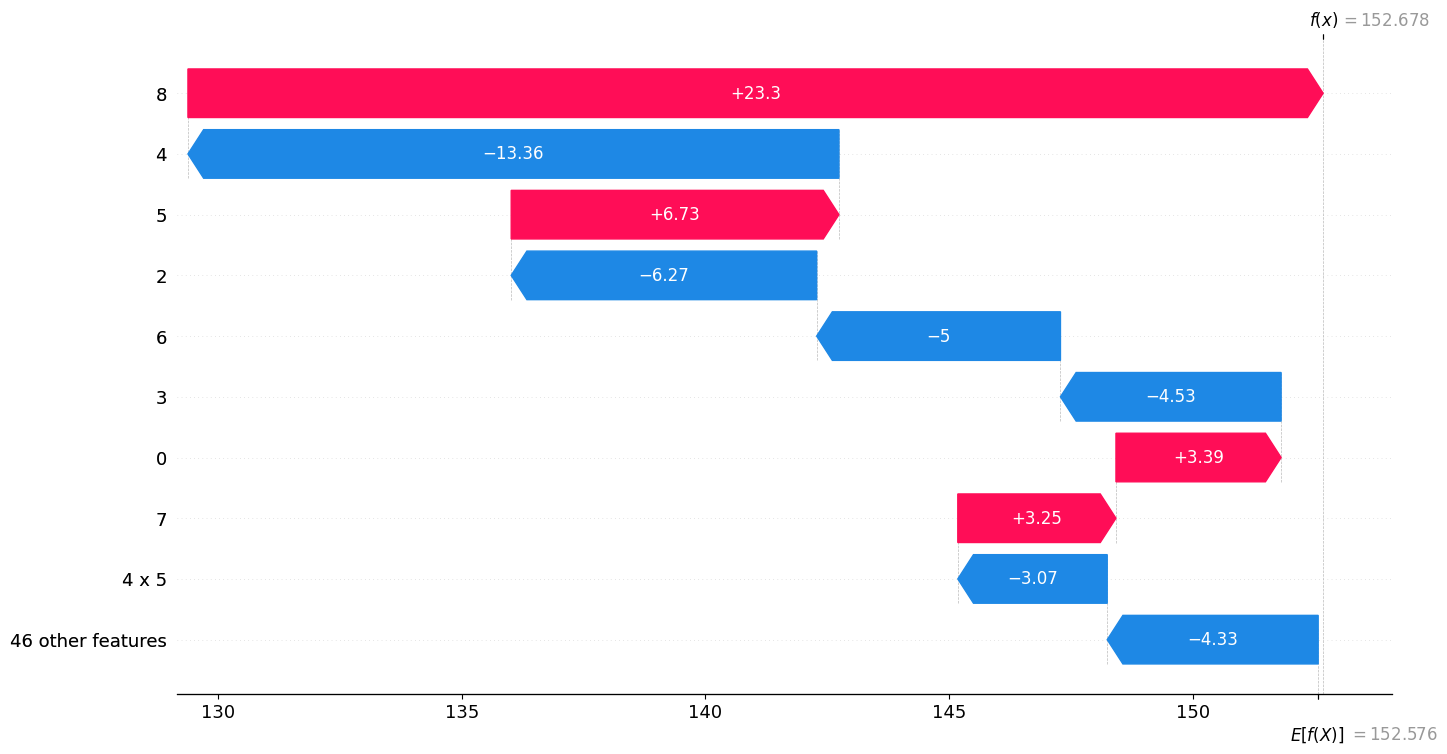

In [11]:
from sklearn.datasets import load_iris, load_diabetes
from sklearn.model_selection import train_test_split
from tabpfn import TabPFNClassifier, TabPFNRegressor
from tabpfn_extensions.interpretability.shapiq import get_tabpfn_imputation_explainer


# create random numerical dataset
X, y = load_diabetes(return_X_y=True, as_frame=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# fit_mode="fit_with_cache" engages the KV-cache fast path; set it BEFORE .fit().
clf = TabPFNRegressor(fit_mode="fit_with_cache").create_default_for_version(ModelVersion.V2_5)
clf.fit(X_train, y_train)
clf.executor_.keep_kv_cache_on_device = True  # keep the KV-cache on device for fast inference

explainer = get_tabpfn_imputation_explainer(model=clf, data=X_train)
sv = explainer.explain(X_test.iloc[0:1].values, budget=128)
sv.plot_waterfall()

In [9]:
X.shape

(442, 10)